## Lecture 9 - (10/03/2026)

Today's Topics:

-  Simple Graph Metrics
- Centrality

In [ ]:
import networkx as nx

### Simple Graph Metrics

Networks come in all different shapes and sizes. Some are quite simple while others are more complex. For this reason, knowing the right metrics is very important in order to better understand what is going on in the network.

#### Degree

The degree of a node is just the number of connections or edges it has. In a directed graph, we break it down into two parts: in-degree (edges coming in) and out-degree (edges going out). Usually, we look at this as a distribution, which comes from the degree sequence.

Knowing a network’s degree sequence (or a node’s degree) helps us understand how many connections each node has. In many networks—especially social ones—most nodes will have a degree around one, since they need at least one connection to be part of the network.

Node 0 has degree 3
Node 1 has degree 2
Node 2 has degree 3
Node 3 has degree 2


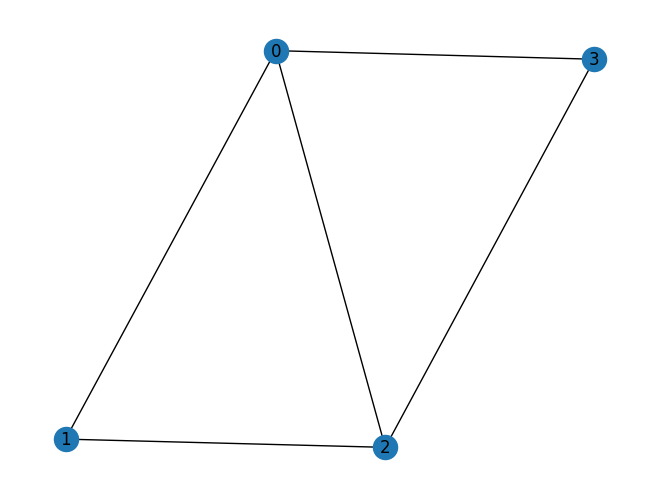

In [14]:
G = nx.path_graph(4)
G.add_edges_from([(0,3),(0,2)])
nx.draw(G, with_labels=True)

for i in range(4):
    print(f"Node {i} has degree {G.degree(i)}")

#### Density

Density (or clustering coefficient) is a handy metric for figuring out how clustered a network is. It’s basically the ratio of how many edges the network actually has compared to the total number of edges it could have if every node was connected to every other node.

This metric gives you a quick snapshot of how many edges are filled in the network. In big, complex networks, this number is usually pretty low. But in smaller, sparse networks, you often get a higher density because there’s a better chance that most of the possible edges are filled.

In [15]:
nx.density(G)

0.8333333333333334

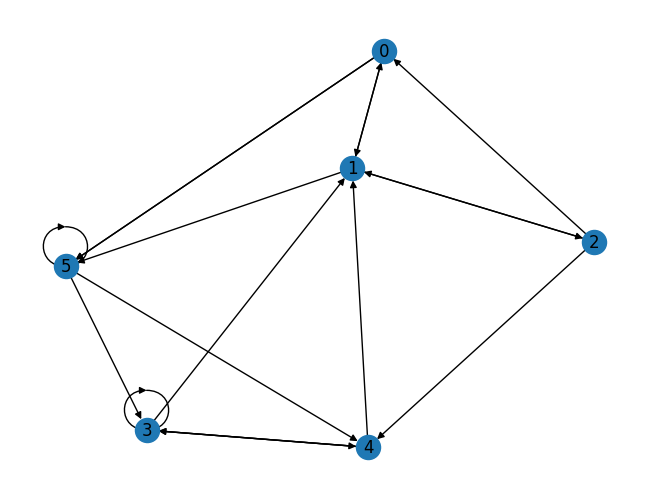

In [34]:
# https://networkx.org/documentation/stable/reference/generated/networkx.generators.directed.gnr_graph.html#networkx.generators.directed.gnr_graph
""
H = nx.random_k_out_graph(6, 3, alpha=1)
nx.draw(H, with_labels=True)

In [19]:
nx.density(H)

0.1

#### Reciprocity

In social network analysis, one useful way to spot meaningful connections is by looking at reciprocity. This only applies to directed networks because we’re talking about ties that go both ways—edges that point in both directions between two nodes.

Why should you care about reciprocity?

Reciprocity is a big deal when it comes to understanding how people interact. Think of it like this: in a social setting, a reciprocated edge might show that one user is replying to another or returning a favour. This can hint that these users prefer to engage with each other more than with others.

With NetworkX, you can measure this easily using a built-in function that gives you a value representing the proportion of reciprocated edges to the total number of edges in the network. The higher the value, the more back-and-forth ties there are. For example, reciprocity is calculated with the following.

In [35]:
nx.reciprocity(H)

0.3333333333333333

#### Transitivity

In network analysis, a triad (basically a group of three nodes) is seen as one of the key building blocks of any network. Transitivity is like the likelihood that connected nodes are all linked together within the network.

It helps show how complete a network is. For example, social interactions like indirect reciprocity (think "the enemy of my enemy is my friend") depend on triads—where three people or entities are involved. Similar to density, transitivity gives a good sense of how interconnected the whole network is.

In [37]:
nx.transitivity(G)

0.75

![image](../attachments/densityvstransivity.png)

#### Modularity

Modularity is a handy metric for figuring out how well a network can be split into different clusters. The basic idea is that the higher the modularity, the more tightly-knit groups you have, with fewer connections between them.

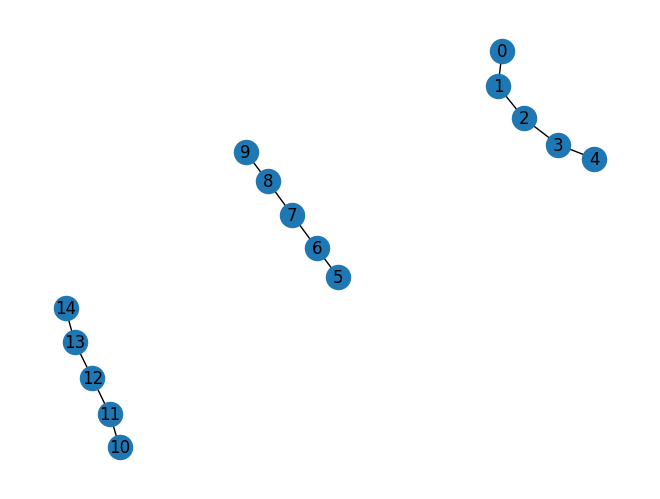

In [ ]:
D1, D2, D3 = nx.path_graph(5), nx.path_graph(5), nx.path_graph(5)

D2 = nx.relabel_nodes(D2, lambda x : x + 5)
D3 = nx.relabel_nodes(D3, lambda x : x + 10)

D = nx.compose_all([D1, D2, D3])

nx.draw(D, with_labels=True)

In [52]:
nx.algorithms.community.modularity(D, [D1, D2, D3])

0.6666666666666666